# Check whether the model is working

**NOTES:**
- The model needs finetuning before being evaluated.
- Currently only numerical features can be used


In [1]:
import sys

sys.path.append("../")
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from mlresearch.datasets import BinaryDatasets
from explainerpfn.base import ExplainerPFN

# just a simple toy dataset (all continuous features)

datasets = BinaryDatasets(names=["BANKNOTE AUTHENTICATION"]).download()
df = datasets["BANKNOTE AUTHENTICATION"]

df_train_rf = df.sample(500, replace=False, random_state=42)
df_train = df.drop(df_train_rf.index).sample(500, replace=False, random_state=42)
df_test = df.drop(df_train_rf.index).drop(df_train.index)

# preprocess data (standardscaler)
scaler = StandardScaler().fit(
    df_train_rf.loc[:, df_train_rf.columns.drop("target")].values
)

Xy = []
for df_ in [df_train_rf, df_train, df_test]:
    df_ = df_.reset_index(drop=True)
    df_.loc[:, df_.columns.drop("target")] = scaler.transform(
        df_.loc[:, df_.columns.drop("target")].values
    )
    X = df_.loc[:, df_.columns.drop("target")].values
    y = df_["target"].values
    Xy.append((X, y))

(X_train_rf, y_train_rf), (X_train, _), (X_test, _) = Xy

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

# Get a classifier, predictions and SHAP explanations

In [2]:
clf = MLPClassifier(
    max_iter=2000, alpha=0.05, learning_rate="invscaling", random_state=42
)
clf.fit(X_train_rf, y_train_rf)

y_train = clf.predict_proba(X_train)[:, 1]
y_test = clf.predict_proba(X_test)[:, 1]

In [3]:
def get_shap_values(X, model, masker=None):
    """
    Get SHAP values for the given model and data.
    """
    xai = shap.Explainer(model=model, masker=masker)

    shap_explanation_train = xai(X).values[:, :, -1]

    return shap_explanation_train

In [4]:
all_shap_values = []
for X, y in tqdm(
    list(zip([X_train, X_test], [y_train, y_test])), desc="Calculating SHAP values"
):
    X_shap = get_shap_values(X, clf.predict_proba, masker=X_train)
    df_shap = pd.DataFrame(
        X_shap.astype(float), columns=df_train.columns.drop("target")
    )
    df_shap["target"] = y
    all_shap_values.append((X_shap, df_shap))

(X_train_shap, df_shap_train), (X_test_shap, df_shap_test) = all_shap_values

Calculating SHAP values:   0%|          | 0/2 [00:00<?, ?it/s]

ExactExplainer explainer: 501it [00:13, 36.64it/s]                          


# Estimating feature importance after model training

In [5]:
xai = ExplainerPFN(model_path="../../explainerpfn_model_DEC_03.ckp", n_estimators=5, random_state=42)
# xai = ExplainerPFN(model_path="../../test_explainerpfn_model_NOV_15_v2_BEST.ckp", random_state=42)
xai.fit(X_train, y_train)
explanations = xai.predict(X_test, y_test, output_type="mean")

In [6]:
from itertools import combinations, permutations
from sklearn.metrics import mean_squared_error

correction_types = ["additive", "multiplicative", "linear", "statistical"]

correction_combinations = [
    combinations(correction_types, r)
    for r in range(1, len(correction_types) + 1)
]
correction_combinations = [combination for sublist in correction_combinations for combination in sublist]
correction_combinations = [permutations(combination) for combination in correction_combinations]
correction_combinations = ["None"] + [list(item) for sublist in correction_combinations for item in sublist]

quality_metrics = {}
for correction_combination in correction_combinations:
    if correction_combination == "None":
        exp_corr = explanations
    else:
        exp_corr = xai.apply_correction(y_test, explanations, kind=correction_combination)

    correlations = [
        np.corrcoef(
            exp_corr[:, i],
            df_shap_test.loc[:, i],
        )[0, 1]
        for i in df_shap_test.columns.drop("target")
    ]
    metrics = [f"corr_{col}" for col in df_shap_test.columns.drop("target")]

    try:
        mse = mean_squared_error(df_shap_test.drop(columns=["target"]).values, exp_corr)
    except ValueError:
        mse = np.nan
    sign_pred = (np.sign(exp_corr) == np.sign(df_shap_test.drop(columns=["target"]).values)).mean()

    name = "->".join(correction_combination) if correction_combination != "None" else "No correction"
    quality_metrics[name] = pd.Series(
        correlations + [mse, sign_pred],
        index=df_shap_test.columns.drop("target").tolist() + ["mse", "sign_accuracy"],
    )
pd.DataFrame(quality_metrics).T.sort_values(by="mse").head(10)

,0,1,2,3,mse,sign_accuracy
statistical->additive,0.918780,0.854656,0.232500,0.007141,0.026062,0.696237
statistical->additive->linear,0.918780,0.854656,0.232500,0.007141,0.026062,0.696237
statistical->additive->linear->multiplicative,0.918780,0.854656,0.232500,0.007141,0.026062,0.696237
statistical->additive->multiplicative,0.918780,0.854656,0.232500,0.007141,0.026062,0.696237
statistical->additive->multiplicative->linear,0.918780,0.854656,0.232500,0.007141,0.026062,0.696237
linear->additive->statistical->multiplicative,0.939317,0.849283,0.197005,0.143313,0.027314,0.707661
linear->additive->multiplicative,0.933892,0.850613,0.194544,0.164871,0.027380,0.704301
linear->additive,0.933892,0.850613,0.194544,0.164871,0.027380,0.704301
statistical->linear->additive,0.935084,0.852064,0.321093,0.234641,0.027985,0.735887
statistical->linear->additive->multiplicative,0.935084,0.852064,0.321093,0.234641,0.027985,0.735887


In [7]:
# NOTE: THIS PART IS EXPERIMENTAL
# df_corrected = df_explanations / df_explanations.std() * X_test.corr().abs()["target"]
# df_corrected = (df_corrected - df_corrected.mean()) / df_corrected.values.std()
# explanations_corrected = (df_corrected * y_test.std() / np.sqrt(X_test.shape[1])).drop(columns="target").values
# 
# explanations_corrected = xai.apply_correction(y_test, explanations, kind=["multiplicative"])
explanations_corrected = xai.apply_correction(y_test, explanations, kind=["linear", "additive"])

In [8]:
df_explanations = pd.DataFrame(
    explanations.astype(float), columns=df_train.columns.drop("target")
)
df_explanations["target"] = y_test
df_explanations_corrected = pd.DataFrame(
    explanations_corrected.astype(float), columns=df_train.columns.drop("target")
)
df_explanations_corrected["target"] = y_test

In [9]:
from tabpfn import TabPFNRegressor

rng = np.random.default_rng(42)
train_indices = rng.choice(X_train_shap.shape[0], size=5, replace=False)

df_shap_train_sample = df_shap_train.iloc[train_indices]
df_train_sample = df_train.iloc[train_indices]

# model.fit(df_train_sample.values, df_shap_train_sample.iloc[:, 0])

tabpfn_preds = np.zeros((df_test.shape[0], df_test.shape[1] - 1), dtype=float)
for i in range(df_test.shape[1] - 1): 
    X_train = df_train_sample.copy().drop(columns=["target"])
    X_train["target"] = df_shap_train_sample["target"].values
    y_train = df_shap_train_sample.iloc[:, i]
    X_test = df_test.copy().drop(columns=["target"])
    X_test["target"] = df_shap_test["target"].values

    model = TabPFNRegressor(n_estimators=1, random_state=42)
    model.fit(X_train.values, y_train)

    pred = model.predict(X_test.values)
    tabpfn_preds[:, i] = pred

print("tabpfn preds", mean_squared_error(df_shap_test.drop(columns=["target"]).values, tabpfn_preds))
print("Sign tabpfn pred:", (np.sign(tabpfn_preds) == np.sign(df_shap_test.drop(columns=["target"]).values)).mean())

tabpfn preds 0.013376973898075961
Sign tabpfn pred: 0.8098118279569892


### Some performance metrics

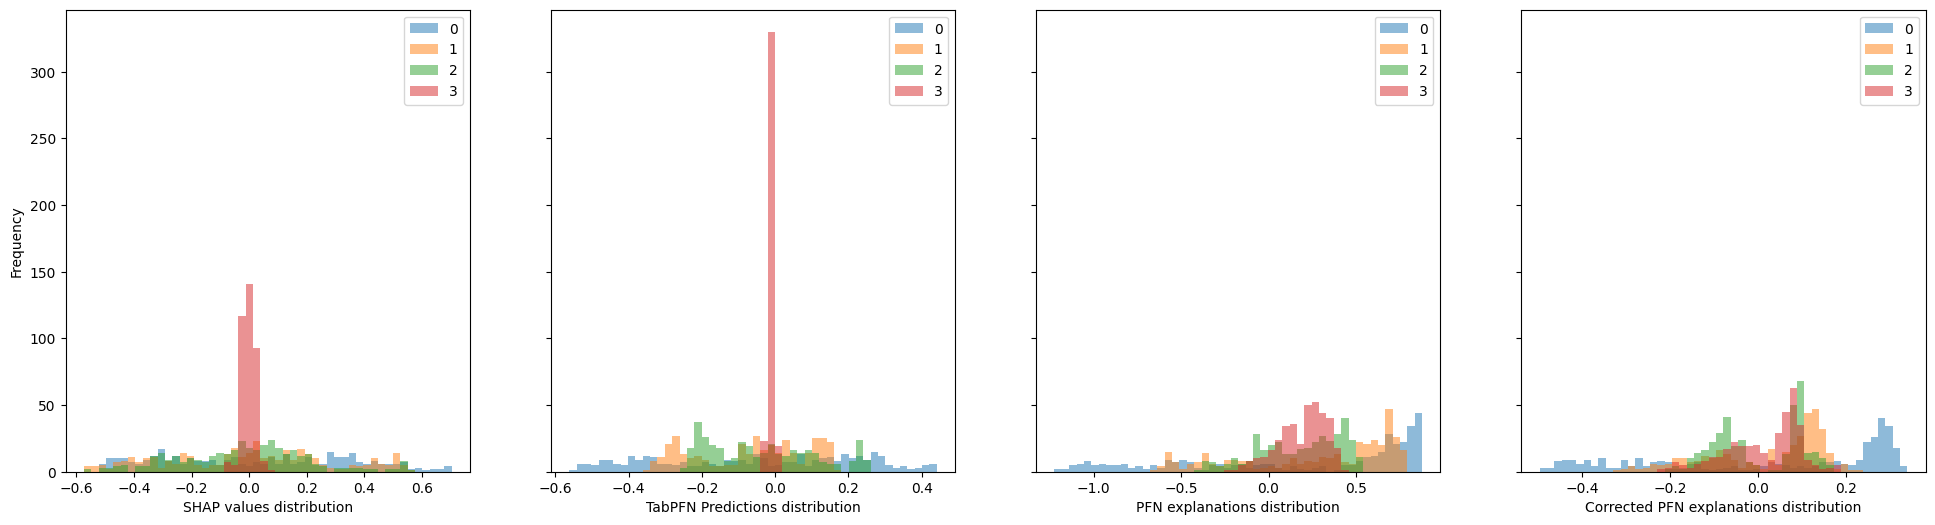

In [10]:
label_data = {
    "SHAP values": df_shap.drop(columns="target"),
    "TabPFN Predictions": pd.DataFrame(tabpfn_preds, columns=df_shap_test.columns[:-1]),
    "PFN explanations": df_explanations.drop(columns="target"),
    "Corrected PFN explanations": df_explanations_corrected.drop(columns="target"),
}

fig, axes = plt.subplots(
    nrows=1, ncols=len(label_data), figsize=(6 * len(label_data), 6), sharey=True
)
for ax, (label, data) in zip(axes, label_data.items()):
    data.plot.hist(
        bins=50,
        alpha=0.5,
        ax=ax,
    )
    ax.set_xlabel(f"{label} distribution")

In [11]:
df_tabpfn_preds = pd.DataFrame(
    tabpfn_preds.astype(float), columns=df_train.columns.drop("target")
)
df_tabpfn_preds["target"] = y_test
pd.Series(
    [
        np.corrcoef(df_tabpfn_preds.loc[:, i], df_shap.loc[:, i])[0, 1]
        for i in df_shap.columns
    ],
    index=df_shap.columns,
)


0         0.979089
1         0.956062
2         0.867477
3         0.739505
target    1.000000
dtype: float64

In [12]:
mean_squared_error(df_shap.drop(columns=["target"]).values, explanations)

0.13849488474156058

In [13]:
mean_squared_error(df_shap.drop(columns=["target"]).values, explanations_corrected)

0.02738014305447924

In [14]:
print("Sign pred baseline:", (np.sign(X_test.drop(columns="target").values) == np.sign(df_shap.drop(columns=["target"]).values)).mean())

Sign pred baseline: 0.2923387096774194


In [15]:
(np.sign(explanations) == np.sign(df_shap.drop(columns=["target"]).values)).mean()

np.float64(0.6518817204301075)

In [16]:
(np.sign(explanations_corrected) == np.sign(df_shap.drop(columns=["target"]).values)).mean()

np.float64(0.7043010752688172)

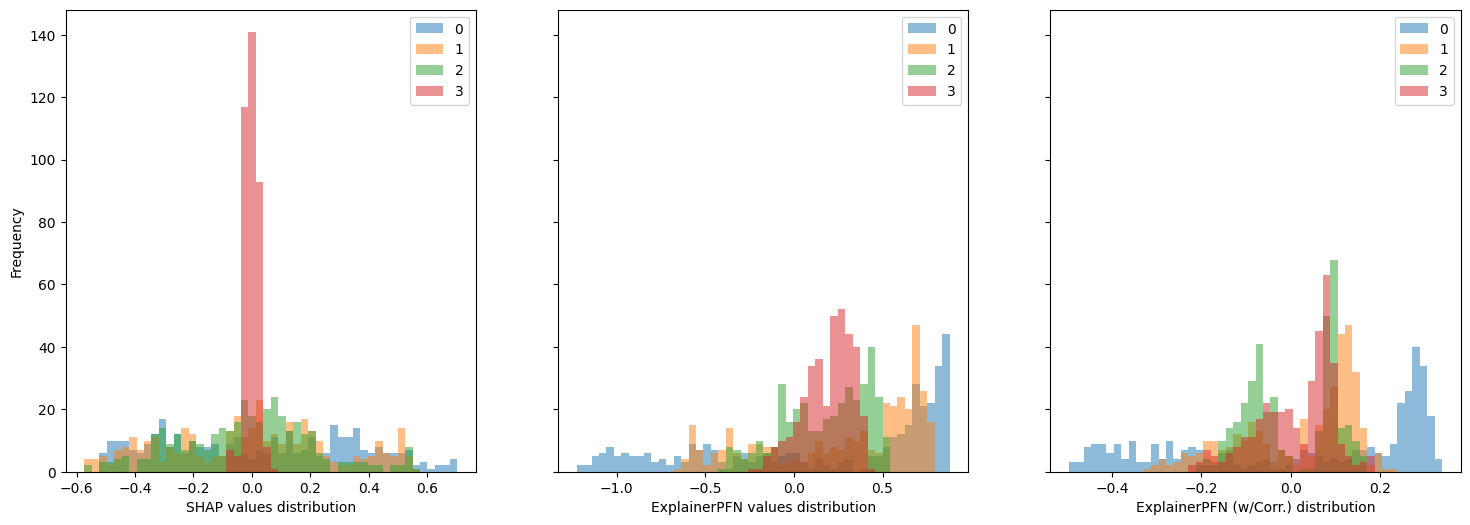

In [17]:
label_data = {
    "SHAP values": df_shap.drop(columns="target"),
    "ExplainerPFN values": df_explanations.drop(columns="target"),
    "ExplainerPFN (w/Corr.)": df_explanations_corrected.drop(columns="target"),
    # "PFN explanations": df_explanations.drop(columns="target"),
    # "Corrected PFN explanations": df_explanations_linear_corrected.drop(columns="target"),
}

fig, axes = plt.subplots(
    nrows=1, ncols=len(label_data), figsize=(6 * len(label_data), 6), sharey=True
)
for ax, (label, data) in zip(axes, label_data.items()):
    data.plot.hist(
        bins=50,
        alpha=0.5,
        ax=ax,
    )
    ax.set_xlabel(f"{label} distribution")

In [18]:
pd.Series(
    [
        np.corrcoef(df_explanations_corrected.loc[:, i], df_shap.loc[:, i])[0, 1]
        for i in df_explanations.columns
    ],
    index=df_explanations.columns,
)


0         0.933892
1         0.850613
2         0.194544
3         0.164871
target    1.000000
dtype: float64

In [19]:
correlations = {}

# Correlation between input values and the predicted target
correlations["input_values_vs_target"] = df.corr()["target"]

# Correlation between shapley values and the predicted target
correlations["shap_vs_target"] = df_shap.corr()["target"]

# Correlation between PFN explanations and the predicted target
df_explanations = pd.DataFrame(
    explanations.astype(float), columns=df_train.columns.drop("target")
)
df_explanations["target"] = y_test
correlations["pfn_exp_vs_target"] = df_explanations.corr()["target"]

# Correlation between the corrected PFN explanations and the predicted target
df_tabpfn_preds = pd.DataFrame(
    tabpfn_preds.astype(float), columns=df_train.columns.drop("target")
)
df_tabpfn_preds["target"] = y_test
correlations["tabpfn_pred_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_tabpfn_preds.loc[:, i], df_shap.loc[:, i])[0, 1]
        for i in df_explanations.columns
    ],
    index=df_explanations.columns,
)


# Correlation between PFN explanations and SHAP values
correlations["pfn_exp_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations.loc[:, i], df_shap.loc[:, i])[0, 1]
        for i in df_explanations.columns
    ],
    index=df_explanations.columns,
)

# Correlation between linear corrected PFN explanations and SHAP values
correlations["pfn_exp_corr_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations_corrected.loc[:, i], df_shap.loc[:, i])[0, 1]
        for i in df_explanations_corrected.columns
    ],
    index=df_explanations_corrected.columns,
)

# Correlation between corrected PFN explanations and SHAP values
# df_explanations_linear = pd.DataFrame(
#     explanations_linear.astype(float), columns=df_train.columns.drop("target")
# )
# df_explanations_linear["target"] = y_test
# correlations["lin_pfn_exp_corr_vs_shap"] = pd.Series(
#     [
#         np.corrcoef(df_explanations_linear.loc[:, i], df_shap.loc[:, i])[0, 1]
#         for i in df_explanations_linear.columns
#     ],
#     index=df_explanations_linear.columns,
# )

# Correlation between linear+corrected PFN explanations and SHAP values
# df_explanations_linear_corrected = pd.DataFrame(
#     explanations_linear_corrected.astype(float), columns=df_train.columns.drop("target")
# )
# df_explanations_linear_corrected["target"] = y_test
# correlations["lin_corr_pfn_exp_corr_vs_shap"] = pd.Series(
#     [
#         np.corrcoef(df_explanations_linear_corrected.loc[:, i], df_shap.loc[:, i])[0, 1]
#         for i in df_explanations_linear_corrected.columns
#     ],
#     index=df_explanations_linear_corrected.columns,
# )

pd.DataFrame(correlations)

,input_values_vs_target,shap_vs_target,pfn_exp_vs_target,tabpfn_pred_vs_shap,pfn_exp_vs_shap,pfn_exp_corr_vs_shap
0,-0.724843,0.829661,0.745657,0.979089,0.893985,0.933892
1,-0.444688,0.659072,0.576966,0.956062,0.875716,0.850613
2,0.155883,0.113648,0.792641,0.867477,-0.259495,0.194544
3,-0.023424,0.141111,0.672258,0.739505,0.326576,0.164871
target,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
def print_agreement(shap_values, pfn_values):
    print("Top positive")
    print("top-1:", (shap_values.argsort(axis=1)[:, -1:] == pfn_values.argsort(axis=1)[:, -1:]).all(axis=1).mean())
    print("top-2:", (shap_values.argsort(axis=1)[:, -2:] == pfn_values.argsort(axis=1)[:, -2:]).all(axis=1).mean())
    print("top-3:", (shap_values.argsort(axis=1)[:, -3:] == pfn_values.argsort(axis=1)[:, -3:]).all(axis=1).mean())
    print("top-4:", (shap_values.argsort(axis=1)[:, -4:] == pfn_values.argsort(axis=1)[:, -4:]).all(axis=1).mean())

    print("Top negative")
    print("top-1:", (shap_values.argsort(axis=1)[:, :1] == pfn_values.argsort(axis=1)[:, :1]).all(axis=1).mean())
    print("top-2:", (shap_values.argsort(axis=1)[:, :2] == pfn_values.argsort(axis=1)[:, :2]).all(axis=1).mean())
    print("top-3:", (shap_values.argsort(axis=1)[:, :3] == pfn_values.argsort(axis=1)[:, :3]).all(axis=1).mean())
    print("top-4:", (shap_values.argsort(axis=1)[:, :4] == pfn_values.argsort(axis=1)[:, :4]).all(axis=1).mean())

    print("Top absolute")
    print("top-1:", (np.abs(shap_values).argsort(axis=1)[:, -1:] == np.abs(pfn_values).argsort(axis=1)[:, -1:]).all(axis=1).mean())
    print("top-2:", (np.abs(shap_values).argsort(axis=1)[:, -2:] == np.abs(pfn_values).argsort(axis=1)[:, -2:]).all(axis=1).mean())
    print("top-3:", (np.abs(shap_values).argsort(axis=1)[:, -3:] == np.abs(pfn_values).argsort(axis=1)[:, -3:]).all(axis=1).mean())
    print("top-4:", (np.abs(shap_values).argsort(axis=1)[:, -4:] == np.abs(pfn_values).argsort(axis=1)[:, -4:]).all(axis=1).mean())

In [21]:
print("Agreement; TabPFN predictions")
print_agreement(df_shap.drop(columns="target").values, tabpfn_preds)

print("Agreement; original PFN explanations")
print_agreement(df_shap.drop(columns="target").values, df_explanations.drop(columns="target").values)

print("Agreement; PFN explanations after output correction")
print_agreement(df_shap.drop(columns="target").values, df_explanations_corrected.drop(columns="target").values)

# print("Agreement; PFN explanations after linear regression correction")
# print_agreement(df_shap.drop(columns="target").values, df_explanations_linear.drop(columns="target").values)
# 
# print("Agreement; PFN explanations after linear regression + output correction")
# print_agreement(df_shap.drop(columns="target").values, df_explanations_linear_corrected.drop(columns="target").values)

Agreement; TabPFN predictions
Top positive
top-1: 0.8494623655913979
top-2: 0.7365591397849462
top-3: 0.5806451612903226
top-4: 0.5806451612903226
Top negative
top-1: 0.782258064516129
top-2: 0.6854838709677419
top-3: 0.5806451612903226
top-4: 0.5806451612903226
Top absolute
top-1: 0.7338709677419355
top-2: 0.5053763440860215
top-3: 0.3978494623655914
top-4: 0.3978494623655914
Agreement; original PFN explanations
Top positive
top-1: 0.478494623655914
top-2: 0.28225806451612906
top-3: 0.12365591397849462
top-4: 0.12365591397849462
Top negative
top-1: 0.553763440860215
top-2: 0.25268817204301075
top-3: 0.12365591397849462
top-4: 0.12365591397849462
Top absolute
top-1: 0.5268817204301075
top-2: 0.2553763440860215
top-3: 0.1693548387096774
top-4: 0.1693548387096774
Agreement; PFN explanations after output correction
Top positive
top-1: 0.4435483870967742
top-2: 0.2956989247311828
top-3: 0.15591397849462366
top-4: 0.15591397849462366
Top negative
top-1: 0.5591397849462365
top-2: 0.293010752

In [22]:
idx_random = np.random.choice(df_shap.index, size=10, replace=False)
df_shap.iloc[idx_random]

,0,1,2,3,target
160,-0.313481,-0.179381,0.007267,0.000181,0.000181
94,-0.306442,-0.323445,0.146014,-0.001119,0.000604
22,-0.307094,-0.353793,0.194839,-0.019411,0.000136
325,0.351419,0.487531,-0.307551,-0.017955,0.999039
95,0.155925,-0.527289,-0.091371,-0.022589,0.000271
109,-0.082149,-0.320564,-0.055510,-0.027004,0.000367
257,0.510644,0.351592,-0.343433,-0.006589,0.997809
47,0.068072,-0.446092,-0.082625,-0.024855,0.000095
274,0.115563,0.220383,0.155114,0.020490,0.997145
132,-0.034580,-0.454895,0.021200,-0.015529,0.001792


In [23]:
df_explanations_corrected.iloc[idx_random]

,0,1,2,3,target
160,-0.302896,-0.038340,-0.124157,0.034695,0.000181
94,-0.266387,-0.145296,-0.044734,0.026141,0.000604
22,-0.388281,-0.091398,-0.035761,0.084698,0.000136
325,0.310883,0.099683,0.093451,0.064144,0.999039
95,0.190686,-0.270569,-0.183789,-0.166935,0.000271
109,0.006447,-0.203112,-0.150155,-0.083691,0.000367
257,0.207894,0.142031,0.122280,0.094726,0.997809
47,0.143049,-0.268129,-0.175459,-0.130244,0.000095
274,0.255733,0.161738,0.075191,0.073604,0.997145
132,0.069632,-0.247270,-0.145821,-0.105628,0.001792


In [24]:
X_test.std()

0         2.821246
1         6.066639
2         4.344871
3         2.077688
target    0.487218
dtype: float64

In [25]:
df_shap.std()

0         0.324791
1         0.286771
2         0.225438
3         0.022173
target    0.487218
dtype: float64

In [62]:
df_shap.corr()

,0,1,2,3,target
0,1.000000,0.375131,-0.114412,-0.105904,0.829661
1,0.375131,1.000000,-0.439678,0.524159,0.659072
2,-0.114412,-0.439678,1.000000,-0.307571,0.113648
3,-0.105904,0.524159,-0.307571,1.000000,0.141111
target,0.829661,0.659072,0.113648,0.141111,1.000000


In [26]:
X_test.corr().abs()["target"]

0         0.707590
1         0.514557
2         0.208412
3         0.050047
target    1.000000
Name: target, dtype: float64

<Axes: ylabel='Frequency'>

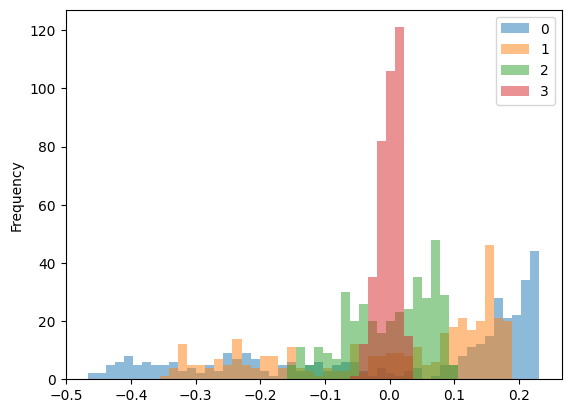

In [27]:
# Experimental correction method
df_corrected = df_explanations / df_explanations.std() * X_test.corr().abs()["target"]
df_corrected = (df_corrected - df_corrected.mean()) / df_corrected.values.std()
df_corrected = df_corrected * y_test.std() / np.sqrt(X_test.shape[1])
df_corrected.drop(columns=["target"]).plot.hist(alpha=0.5, bins=50)

In [68]:
df_corrected.iloc[:, :-1] = xai.apply_correction(y_test, df_corrected.drop(columns="target").values, kind=["statistical", "additive"])

In [69]:
mean_squared_error(df_shap.drop(columns=["target"]).values, df_corrected.drop(columns=["target"]).values)

0.024643115709106548

In [70]:
xai.feature_exp_std_, xai.y_train_std_

(np.float64(0.4819173257164045), np.float64(0.4819173257164045))